In [ ]:
# Ensure working directory to project code folder
import os
from importlib import reload

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [33]:
# set matplotlib params to roughly match A0 poster
from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
reload(plt)

<module 'matplotlib.pyplot' from '/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/matplotlib/pyplot.py'>

## basic behaviour plots

In [8]:
# load analysis modules
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.behaviour import navigation_strategies as ns

In [ ]:
# generate data
basic_behaviour_df = pm.get_basic_behaviour_df()
strategy_weights_df = ns.get_strategy_weights_across_subjects()

navigation_strategies.parquet not found for m8.2022-07-26.maze


/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


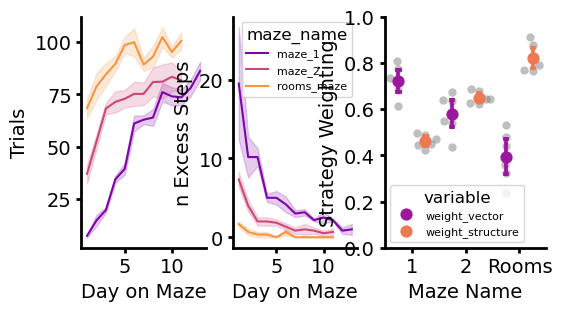

In [21]:
reload(pm)
reload(ns)
f, axes = plt.subplots(1, 3, figsize=(6, 3), clear=True, width_ratios=[1, 1, 1.3])
pm._plot_trials(basic_behaviour_df, ax=axes[0], legend=False, cmap="plasma", print_stats=False)
pm._plot_n_excess_steps(basic_behaviour_df, ax=axes[1], legend=True, cmap="plasma", print_stats=False)
ns.plot_strategy_weights_cross_subject(
    strategy_weights_df, mazes=["maze_1", "maze_2", "rooms_maze"], ax=axes[2], colormap="plasma"
)
f.savefig("../results/temp/sfn/behaviour.pdf")

## Place-direction results

In [ ]:
# load analysis modules

from GridMaze.analysis.place_direction import efficient_coding as ec

In [ ]:
# run analysis
maze_name = "maze_2"
auc_df, ve_df = ec.get_neural_variance_explained_by_synthetic_behaviour(maze_name)

comparison p-values:
                optimal  random_diffusion  true_behaviour
neural_data         0.0               0.0           0.002
true_behaviour      0.0               0.0             NaN


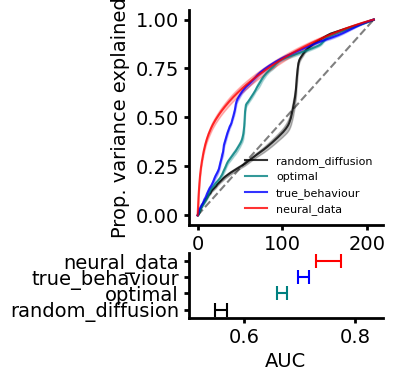

In [ ]:
# plot
f, axes = plt.subplots(2, 1, figsize=(2.5, 4), height_ratios=(1, 0.3), clear=True)
ec.plot_neural_behavioural_ve_summary(
    auc_df, ve_df, axes=axes, colors=["red", "blue", "teal", "black"], print_stats=True
)
f.savefig("../results/temp/sfn/efficient_coding.pdf")

In [28]:
from GridMaze.analysis.place_direction import future_decoding as fd

In [29]:
summary_df = fd.get_place_decoding_summary()

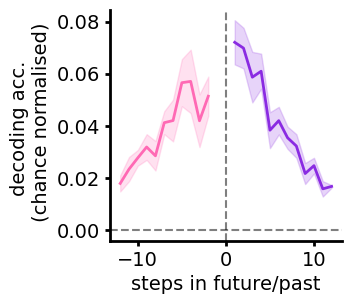

In [ ]:
reload(fd)
f, ax = plt.subplots(1, 1, figsize=(3, 3))
fd.plot_future_decoding_summary(summary_df, decision_points="future", plot_as="diff", ax=ax)
f.savefig("../results/temp/sfn/future_decoding.pdf")